# Modeling the Performance of Energeting Materials

## Background of this study


----
## 1. Detonation Pressure Evolution During KNSB Ignition

### 1.1 Understanding KNSB Stoichiometry
| Component | Formula | Molecular weight (g/mol) | Role in 100g Batch | Moles |
| --- | --- | --- | --- | --- |
| Potassium nitrate | $KNO_3$ | 101.10 | 65g - oxidiser | 0.6429 |
| Sorbitol | $C_6H_{14}O_6$ | 182.17 | 35g - fuel/binder | 0.1921 | 

### 1.2 Modified Decompostion Path for K-Containing Propellants
> **Why the -11.2 correction matters**:

### 1.3 Python: Computing and Plotting $P_det$ vs Desnity ($\rho$)
#### Setting up the environment


In [1]:
# ══════════════════════════════════════════════════════════════
# KNSB Detonation Pressure Evolution — Chapter 11, K-J Model
# Uses Keshavarz (2025) Eqs. 11.13 and 11.14
# ══════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

#### Step 1: Compute atomic contributions from each component

In [2]:
MW_KNO3     = 101.10   # g/mol
MW_sorbitol = 182.17   # g/mol — C₆H₁₄O₆
mass_KNO3   = 65.0     # g
mass_sorb   = 35.0     # g

mol_KNO3  = mass_KNO3  / MW_KNO3     # = 0.6429 mol
mol_sorb  = mass_sorb  / MW_sorbitol  # = 0.1921 mol

# Atomic totals per 100 g batch
n_K = mol_KNO3                     # 0.6429 K atoms
n_C = mol_sorb * 6                # 1.1526 C
n_H = mol_sorb * 14               # 2.6894 H
n_N = mol_KNO3 * 1                # 0.6429 N
n_O = mol_KNO3 * 3 + mol_sorb * 6 # 3.0816 O
M_total = 100.0                   # g (per batch)

#### Step 2: Modified Decomposition Path
> Priority: $K$ → $\frac{1}{2}K_2O$ (consuming $O$), then $H$ → $H_2O$, then $C$ → $\frac{CO_2}{CO}$

In [3]:
O_after_K = n_O - (0.5 * n_K)   # O remaining after K scavenging
O_for_H2O = min(n_H / 2, O_after_K)
n_H2O     = O_for_H2O
O_remain  = O_after_K - O_for_H2O
n_CO2     = min(n_C, O_remain / 2)
O_remain2 = O_remain - 2 * n_CO2
n_CO      = min(n_C - n_CO2, O_remain2)
n_C_free  = n_C - n_CO2 - n_CO
n_N2      = n_N / 2

# Gaseous products (per 100 g batch) - assuming complete combustion
gas_products = {
    'H2O': n_H2O,
    'CO2': n_CO2,
    'CO':  n_CO,
    'N2':  n_N2,
}

n_gas_total = sum(gas_products.values())                # total gas moles
n_gas_star  = n_gas_total / M_total                     # moles per gram

MW_gas_dict = {'H2O': 18.02, 'CO2': 44.01, 'CO': 28.01, 'N2': 28.02}
Mwgas = sum(gas_products[g] * MW_gas_dict[g] for g in gas_products) / n_gas_total

#### Step 3: Detonation Heat, $Q_{det}$

In [5]:
# Using standard heats of formation (kJ/mol)
hf = {
    'KNO3_s':   -494.6,  # kJ/mol
    'sorbitol_s': -1343.9,  # kJ/mol (C₆H₁₄O₆)
    'H2O_g':   -241.8,
    'CO2_g':   -393.5,
    'CO_g':    -110.5,
    'N2_g':       0.0,
    'K2O_s':   -363.2,
}

H_reactants = mol_KNO3 * hf['KNO3_s'] + mol_sorb * hf['sorbitol_s']
H_products  = (n_H2O * hf['H2O_g'] + n_CO2 * hf['CO2_g']
               + n_CO * hf['CO_g'] + n_N2 * hf['N2_g']
               + (n_K/2) * hf['K2O_s'])

Q_det_kJ_batch = H_reactants - H_products   # kJ (positive = exothermic)
Q_det = Q_det_kJ_batch / M_total             # kJ/g
print(f"Q_det = {Q_det:.3f} kJ/g")

Q_det = 1.442 kJ/g


#### Step 4: Sweep density $ρ_o$ and compute $P_{det}$

In [6]:
rho = np.linspace(0.8, 1.85, 200)   # loading density range (g/cm³)

# Kamlet-Jacobs (Eq. 11.13) — ideal baseline
phi     = n_gas_star * Mwgas * Q_det         # K-J phi parameter
P_KJ    = 240.86 * n_gas_star * Mwgas * (Q_det**0.5) * rho**2

# Modified K-J (Eq. 11.14) — Keshavarz preferred
P_modKJ = 245 * n_gas_star * Mwgas * (Q_det**0.5) * rho**2 - 11.2

#### Step 5: Plot

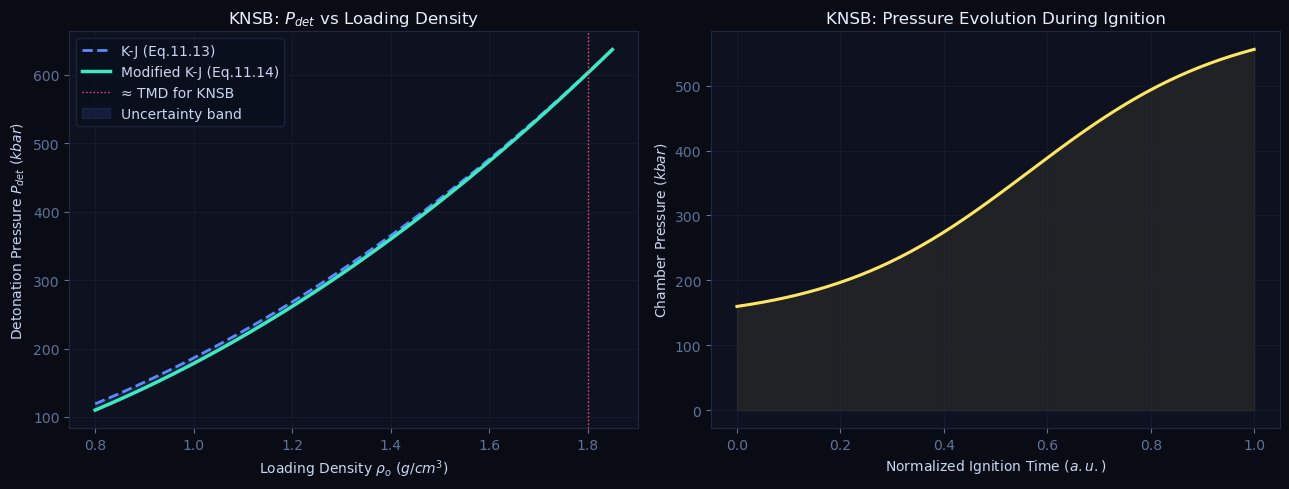

In [12]:
import os

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#090c14')

for ax in axes:
    ax.set_facecolor('#0e1220')
    ax.tick_params(colors='#5e7399')
    for spine in ax.spines.values():
        spine.set_color('#1e2840')

# Left: P vs density
axes[0].plot(rho, P_KJ,    color='#5b8aff', lw=2,   label='K-J (Eq.11.13)', linestyle='--')
axes[0].plot(rho, P_modKJ, color='#3ee8c0', lw=2.5, label='Modified K-J (Eq.11.14)')
axes[0].axvline(1.80, color='#ff4e6a', ls=':', lw=1, label='≈ TMD for KNSB')
axes[0].fill_between(rho, P_KJ, P_modKJ, alpha=0.12, color='#5b8aff',
                      label='Uncertainty band')
axes[0].set_xlabel(r'Loading Density $\rho_o$ ($g/cm^3$)', color='#c8d6f0')
axes[0].set_ylabel(r'Detonation Pressure $P_{det}$ ($kbar$)', color='#c8d6f0')
axes[0].set_title(r'KNSB: $P_{det}$ vs Loading Density', color='#e8f0ff')
axes[0].legend(facecolor='#0a0f1e', edgecolor='#1e2840', labelcolor='#c8d6f0')
axes[0].grid(color='#1e2840', alpha=0.4)

# Right: Pressure-time proxy (rho as proxy for burn front progression)
t = np.linspace(0, 1, 200)           # normalized time
rho_t = 0.95 + 0.85 * ((1 - np.exp(-5*t)) / (1 + np.exp(-5*(t-0.5))))
P_t = 245 * n_gas_star * Mwgas * (Q_det**0.5) * rho_t**2 - 11.2
axes[1].plot(t, P_t, color='#ffe566', lw=2.2)
axes[1].fill_between(t, 0, P_t, alpha=0.08, color='#ffe566')
axes[1].set_xlabel(r'Normalized Ignition Time ($a.u.$)', color='#c8d6f0')
axes[1].set_ylabel(r'Chamber Pressure ($kbar$)', color='#c8d6f0')
axes[1].set_title('KNSB: Pressure Evolution During Ignition', color='#e8f0ff')
axes[1].grid(color='#1e2840', alpha=0.4)

output_dir = "../share/images"
os.makedirs(output_dir, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'knsb_pressure_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Important modeling caveat:** KNSB is primarily a deflagrant (burning propellant), not a detonating explosive. Its Chapman-Jouguet parameters are best interpreted as upper-bound pressure estimates — useful for stress analysis of containment hardware, not as an accurate description of steady-state detonation. The burn rate of KNSB is pressure-dependent (following Vielle's law, r = a·Pⁿ where n ≈ 0.3–0.4), so a more rigorous model would couple these K-J outputs to a ballistic simulation.

## 2. What we can learn from this simulation

## 3. Conclusion

## References
[1] Keshavarz ML, 'Modeling of Energetic Materials', Springer Nature.....(IEEE format)